In [1]:
import torch
from torch import nn
import wandb

networks = [nn.Linear(384, 32) for _ in range(8)]
wandb.init()
weight_artifact = wandb.use_artifact("yoshi-0921/LangStrat-exp/1adr04sv.pth:v11", type="pretrained_weight")
weight_artifact_dir = weight_artifact.download()
for agent_id, network in enumerate(networks):
    state_dict = torch.load(weight_artifact_dir + f"/agent{agent_id}.pth", map_location="cpu")
    fc_pth = {k.replace("fc0.",""):state_dict[k] for k in ["fc0.weight","fc0.bias"]}
    network.load_state_dict(fc_pth)


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yoshi-0921 (use `wandb login --relogin` to force relogin)
wandb: wandb version 0.27.0 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade


In [2]:
root_dir = "/home/motokawa/projects/MAEXP/configs/experiments/LangStrat/tensors/"
type0_right_tensor = torch.load(root_dir + "type0_right_tensor")
type0_left_tensor = torch.load(root_dir + "type0_left_tensor")
type0_top_tensor = torch.load(root_dir + "type0_top_tensor")
type0_bottom_tensor = torch.load(root_dir + "type0_bottom_tensor")
type1_right_tensor = torch.load(root_dir + "type1_right_tensor")
type1_left_tensor = torch.load(root_dir + "type1_left_tensor")
type1_top_tensor = torch.load(root_dir + "type1_top_tensor")
type1_bottom_tensor = torch.load(root_dir + "type1_bottom_tensor")
unseen_type0_right_tensor = torch.load(root_dir + "unseen_type0_right_tensor")
unseen_type0_left_tensor = torch.load(root_dir + "unseen_type0_left_tensor")
unseen_type0_top_tensor = torch.load(root_dir + "unseen_type0_top_tensor")
unseen_type0_bottom_tensor = torch.load(root_dir + "unseen_type0_bottom_tensor")
unseen_type1_right_tensor = torch.load(root_dir + "unseen_type1_right_tensor")
unseen_type1_left_tensor = torch.load(root_dir + "unseen_type1_left_tensor")
unseen_type1_top_tensor = torch.load(root_dir + "unseen_type1_top_tensor")
unseen_type1_bottom_tensor = torch.load(root_dir + "unseen_type1_bottom_tensor")

<AxesSubplot:>

<Figure size 1000x2000 with 0 Axes>

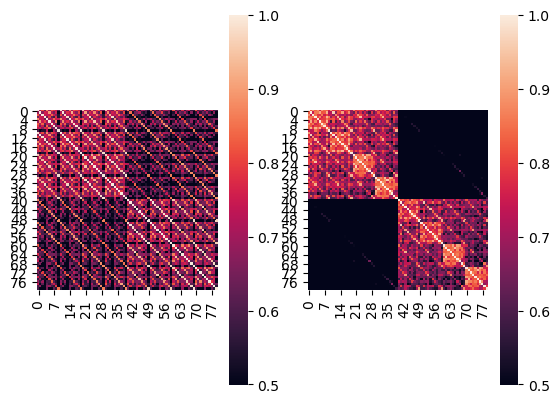

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

embeddings = torch.concat([type0_right_tensor,type0_left_tensor,type0_top_tensor,type0_bottom_tensor,type1_right_tensor,type1_left_tensor,type1_top_tensor,type1_bottom_tensor])
trained_embeddings = networks[0](torch.concat([type0_right_tensor,type0_left_tensor,type0_top_tensor,type0_bottom_tensor,type1_right_tensor,type1_left_tensor,type1_top_tensor,type1_bottom_tensor]))

final = []
for i in range(len(embeddings)):
    ans = []
    for j in range(len(embeddings)):
        similarity = torch.cosine_similarity(embeddings[i].view(1,-1),embeddings[j].view(1,-1)).item()
        ans.append(similarity)
    final.append(ans)

trained_final = []
for i in range(len(trained_embeddings)):
    ans = []
    for j in range(len(trained_embeddings)):
        similarity = torch.cosine_similarity(trained_embeddings[i].view(1,-1),trained_embeddings[j].view(1,-1)).item()
        ans.append(similarity)
    trained_final.append(ans)


plt.figure(figsize=(10, 20)) 

fig = plt.figure()
plt.subplot(1, 2, 1)
sns.heatmap(
    final,
    square=True,
    annot=False,
    vmin=0.5
    )
plt.subplot(1, 2, 2)
sns.heatmap(trained_final,
    square=True,
    annot=False,
    vmin=0.5
    )


<AxesSubplot:>

<Figure size 1000x2000 with 0 Axes>

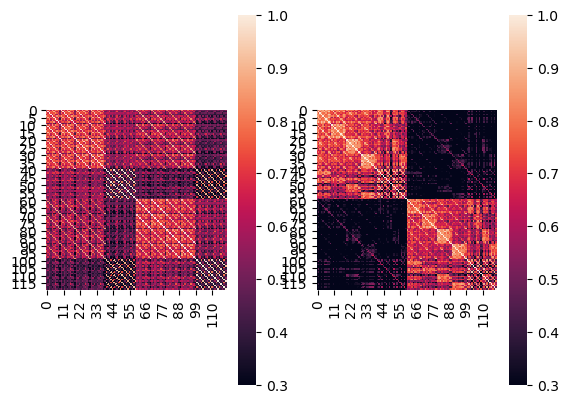

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# embeddings = torch.concat([type0_right_tensor,unseen_type0_right_tensor,type0_left_tensor,unseen_type0_left_tensor,type0_top_tensor,unseen_type0_top_tensor,type0_bottom_tensor,unseen_type0_bottom_tensor,type1_right_tensor,unseen_type1_right_tensor,type1_left_tensor,unseen_type1_left_tensor,type1_top_tensor,unseen_type1_top_tensor,type1_bottom_tensor,unseen_type1_bottom_tensor])

embeddings = torch.concat([type0_right_tensor,type0_left_tensor,type0_top_tensor,type0_bottom_tensor,unseen_type0_right_tensor,unseen_type0_left_tensor,unseen_type0_top_tensor,unseen_type0_bottom_tensor,type1_right_tensor,type1_left_tensor,type1_top_tensor,type1_bottom_tensor,unseen_type1_right_tensor,unseen_type1_left_tensor,unseen_type1_top_tensor,unseen_type1_bottom_tensor
                           ])
                        #    ,torch.normal(0,0.05,size=(10,384))])

trained_embeddings = networks[0](embeddings)

final = []
for i in range(len(embeddings)):
    ans = []
    for j in range(len(embeddings)):
        similarity = torch.cosine_similarity(embeddings[i].view(1,-1),embeddings[j].view(1,-1)).item()
        ans.append(similarity)
    final.append(ans)

trained_final = []
for i in range(len(trained_embeddings)):
    ans = []
    for j in range(len(trained_embeddings)):
        similarity = torch.cosine_similarity(trained_embeddings[i].view(1,-1),trained_embeddings[j].view(1,-1)).item()
        ans.append(similarity)
    trained_final.append(ans)


plt.figure(figsize=(10, 20)) 

fig = plt.figure()
plt.subplot(1, 2, 1)
sns.heatmap(
    final,
    square=True,
    annot=False,
    vmin=0.3
    )
plt.subplot(1, 2, 2)
sns.heatmap(trained_final,
    square=True,
    annot=False,
    vmin=0.3
    )


<Figure size 2000x3000 with 0 Axes>

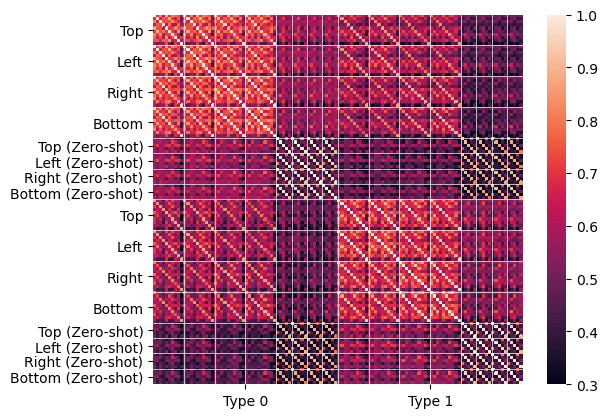

In [98]:
plt.figure(figsize=(20, 30)) 
fig = plt.figure()
ax=sns.heatmap(final, # final, trained_final
    square=True,
    annot=False,
    vmin=0.3,
    )

# type0_right_tensor,type0_left_tensor,type0_top_tensor,type0_bottom_tensor

ax.set_xticks([30,90])
ax.set_xticklabels(['Type 0', 'Type 1'], rotation=0, ha='center')

ax.set_yticks([5,15,25,35,42.5,47.5,52.5,57.5,65,75,85,95,102.5,107.5,112.5,117.5])
ax.set_yticklabels(['Top', 'Left', 'Right', 'Bottom', 'Top (Zero-shot)', 'Left (Zero-shot)', 'Right (Zero-shot)', 'Bottom (Zero-shot)',
                    'Top', 'Left', 'Right', 'Bottom', 'Top (Zero-shot)', 'Left (Zero-shot)', 'Right (Zero-shot)', 'Bottom (Zero-shot)'])

ax.axhline(10, color='white',lw=0.5)
ax.axvline(10, color='white',lw=0.5)
ax.axhline(20, color='white',lw=0.5)
ax.axvline(20, color='white',lw=0.5)
ax.axhline(30, color='white',lw=0.5)
ax.axvline(30, color='white',lw=0.5)
ax.axhline(40, color='white',lw=0.5)
ax.axvline(40, color='white',lw=0.5)
ax.axhline(45, color='white',lw=0.5)
ax.axvline(45, color='white',lw=0.5)
ax.axhline(50, color='white',lw=0.5)
ax.axvline(50, color='white',lw=0.5)
ax.axhline(55, color='white',lw=0.5)
ax.axvline(55, color='white',lw=0.5)
ax.axhline(60, color='white',lw=0.5)
ax.axvline(60, color='white',lw=0.5)

ax.axhline(70, color='white',lw=0.5)
ax.axvline(70, color='white',lw=0.5)
ax.axhline(80, color='white',lw=0.5)
ax.axvline(80, color='white',lw=0.5)
ax.axhline(90, color='white',lw=0.5)
ax.axvline(90, color='white',lw=0.5)
ax.axhline(100, color='white',lw=0.5)
ax.axvline(100, color='white',lw=0.5)
ax.axhline(105, color='white',lw=0.5)
ax.axvline(105, color='white',lw=0.5)
ax.axhline(110, color='white',lw=0.5)
ax.axvline(110, color='white',lw=0.5)
ax.axhline(115, color='white',lw=0.5)
ax.axvline(115, color='white',lw=0.5)

fig.savefig("trained_embedding_similarity.pdf", dpi=300, bbox_inches='tight')

In [80]:
type0_right_tensor.std()

tensor(0.0510)